In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

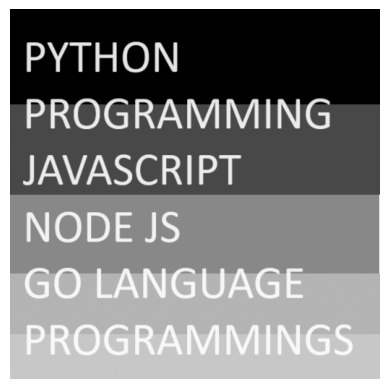

In [2]:
img = cv2.imread('../image/gray2.png',0)
plt.imshow(img,cmap='gray')
plt.axis('off')
plt.show()

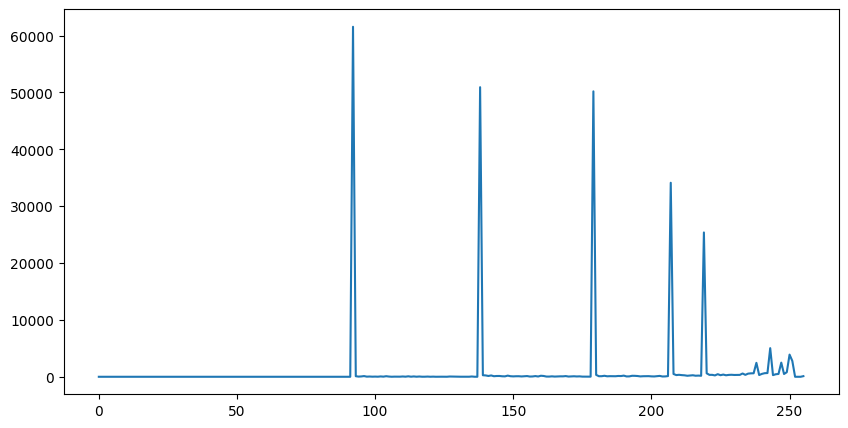

In [3]:
hist = cv2.calcHist([img],[0],None,[256],[0,256])
plt.figure(figsize=(10,5))
plt.plot(hist)
plt.show()

In [4]:
def float2int(num) :
    if num - math.floor(num) > 0.5 :
        return math.ceil(num)
    else :
        return math.floor(num)

In [5]:
def plothist(hist,st,en) :
    plt.figure(figsize=(10,5))
    plt.plot(hist[st:en])
    plt.show()
    
def intermean(hist,thr,st,en) :
    prob = np.zeros_like(hist).astype('float')
    prob[st:en] = hist[st:en]/np.sum(hist[st:en])
    
    w0 = np.sum(prob[st:thr]) + 0.0001
    w1 = np.sum(prob[thr:en]) + 0.0001
    
    indices = np.arange(0,256)
    u0 = np.sum(indices[st:thr]*prob[st:thr])/w0
    u1 = np.sum(indices[thr:en]*prob[thr:en])/w1
    
    if u0 == 0.0 :
        return u1
    elif u1 == 0.0 :
        return u0
    else :
        return float2int((u0+u1)/2)
    

In [ ]:
def intermean_method(hist,st,en) :
    thr_list = []
    thr = float2int((st+en)*0.5)
    thr_list.append(thr)
    while(True) :
        t1 = intermean(hist,thr,st,en)
        thr_list.append(t1)
        if abs(t1-thr) <= 1 :
            break
        else :
            thr = t1
    return thr_list[-1]

def intermean_loop(hist) :
    hist = hist.flatten()i
    st , en = 0 , 256
    for i in range(3) :
        plothist(hist,st,en) 
        thr = intermean_method(hist,st,en)
        st = thr + 1
    return thr

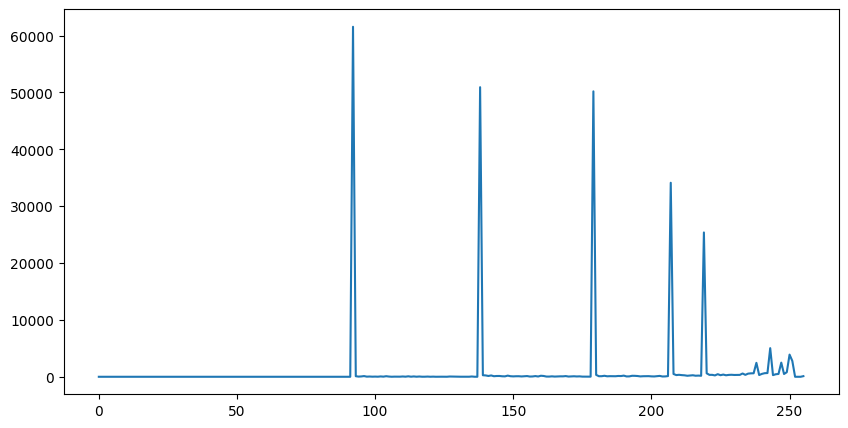

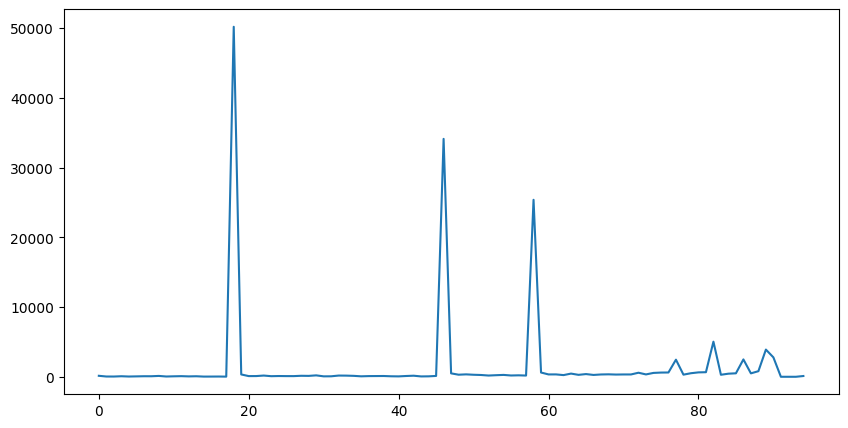

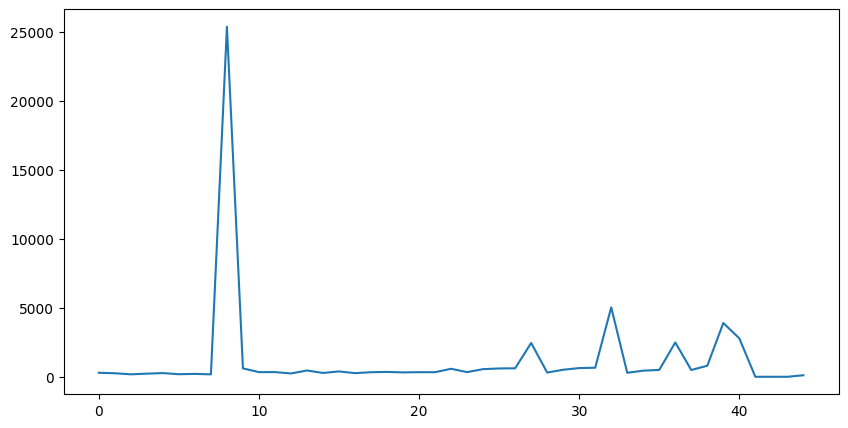

True

In [7]:
thr = intermean_loop(hist)
out = np.zeros_like(img,dtype='uint8')
out[img > thr] = 255
cv2.imwrite('gray2_intermeanLoop.jpg',out)